In [1]:
import numpy as np 
import pandas as pd 
import os
import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img,img_to_array
print(tf.__version__)

2.10.0


In [2]:
physical_devices = tf.config.experimental.list_physical_devices('GPU')
print("Num GPUs Available: ", len(physical_devices))
tf.config.experimental.set_memory_growth(physical_devices[0], True)

Num GPUs Available:  1


In [3]:
# Create a list with the filepaths for training and testing
train_dir = Path(r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/MobileNet_Test/Bangla_Food/train')
train_filepaths = list(train_dir.glob(r'**/*.jpg'))

In [4]:
test_dir = Path(r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/MobileNet_Test/Bangla_Food/test')
test_filepaths = list(test_dir.glob(r'**/*.jpg'))

val_dir = Path(r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/MobileNet_Test/Bangla_Food/valid')
val_filepaths = list(test_dir.glob(r'**/*.jpg'))

In [5]:
def image_processing(filepath):
    labels = [str(filepath[i]).split("\\")[-2] \
        for i in range(len(filepath))]
    filepath = pd.Series(filepath, name='Filepath').astype(str)
    labels = pd.Series(labels, name='Label')
    df = pd.concat([filepath, labels], axis=1)
    df = df.sample(frac=1).reset_index(drop = True)
    return df

In [6]:
train_df = image_processing(train_filepaths)
test_df = image_processing(test_filepaths)
val_df = image_processing(val_filepaths)

In [7]:
print('-- Training set --\n')
print(f'Number of pictures: {train_df.shape[0]}\n')
print(f'Number of different labels: {len(train_df.Label.unique())}\n')
print(f'Labels: {train_df.Label.unique()}')

-- Training set --

Number of pictures: 5415

Number of different labels: 58

Labels: ['cheesecake' 'Salad' 'Chicken_curry' 'pizza' 'Sandwich' 'Fried_rice'
 'Chicken_wings' 'Chocolate_cake' 'French_fries' 'Doi'
 'Meat Curry_Gosht Bhuna' 'cup_cakes' 'Kacchi' 'Fish Bhuna_Mach Bhuna'
 'Shemai' 'kebab - Gosht Kebab' 'Sondesh' 'Jalebi' 'Begun Bhorta'
 'Begun Bhaja' 'Biriyani' 'Chitoi  Pitha' 'Alu Bhorta' 'omelette' 'Misti'
 'Cake' 'Fried chicken - Murg Bhaja' 'ice_cream' 'Chicken_Grill'
 'Rosogolla' 'Mixed vegetable stir-fry - Torkari'
 'Vegetable fritters - Beguni' 'Borhani' 'Singgara' 'Shik_kabab'
 'Lentil fritters - Dal Puri' 'Lentil soup_Dal' 'Noodles' 'Boiled_egg'
 'poached_egg' 'Hilsha_Fish_Curry' 'Vapa Pitha' 'Falooda'
 'Fried fish_Mach Bhaja' 'Shak-Vaji' 'Momo' 'Fuchka' 'Burger'
 'Prawn curry - Chingri bhuna' 'Payesh-Firni' 'Parata' 'Korola-Vaji'
 'Jorda' 'Lal-shak-Vaji' 'Khichuri' 'Shawarma' 'Alu-Vaji'
 'Tundul ruti - Nan Ruti']


In [8]:
train_df.head(58)

,Filepath,Label
0,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,cheesecake
1,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Salad
2,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Chicken_curry
3,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,pizza
4,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Sandwich
5,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Fried_rice
6,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Chicken_wings
7,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,Chocolate_cake
8,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,pizza
9,C:\Users\Rafin\OneDrive\Desktop\NSU\NSU 10th S...,French_fries


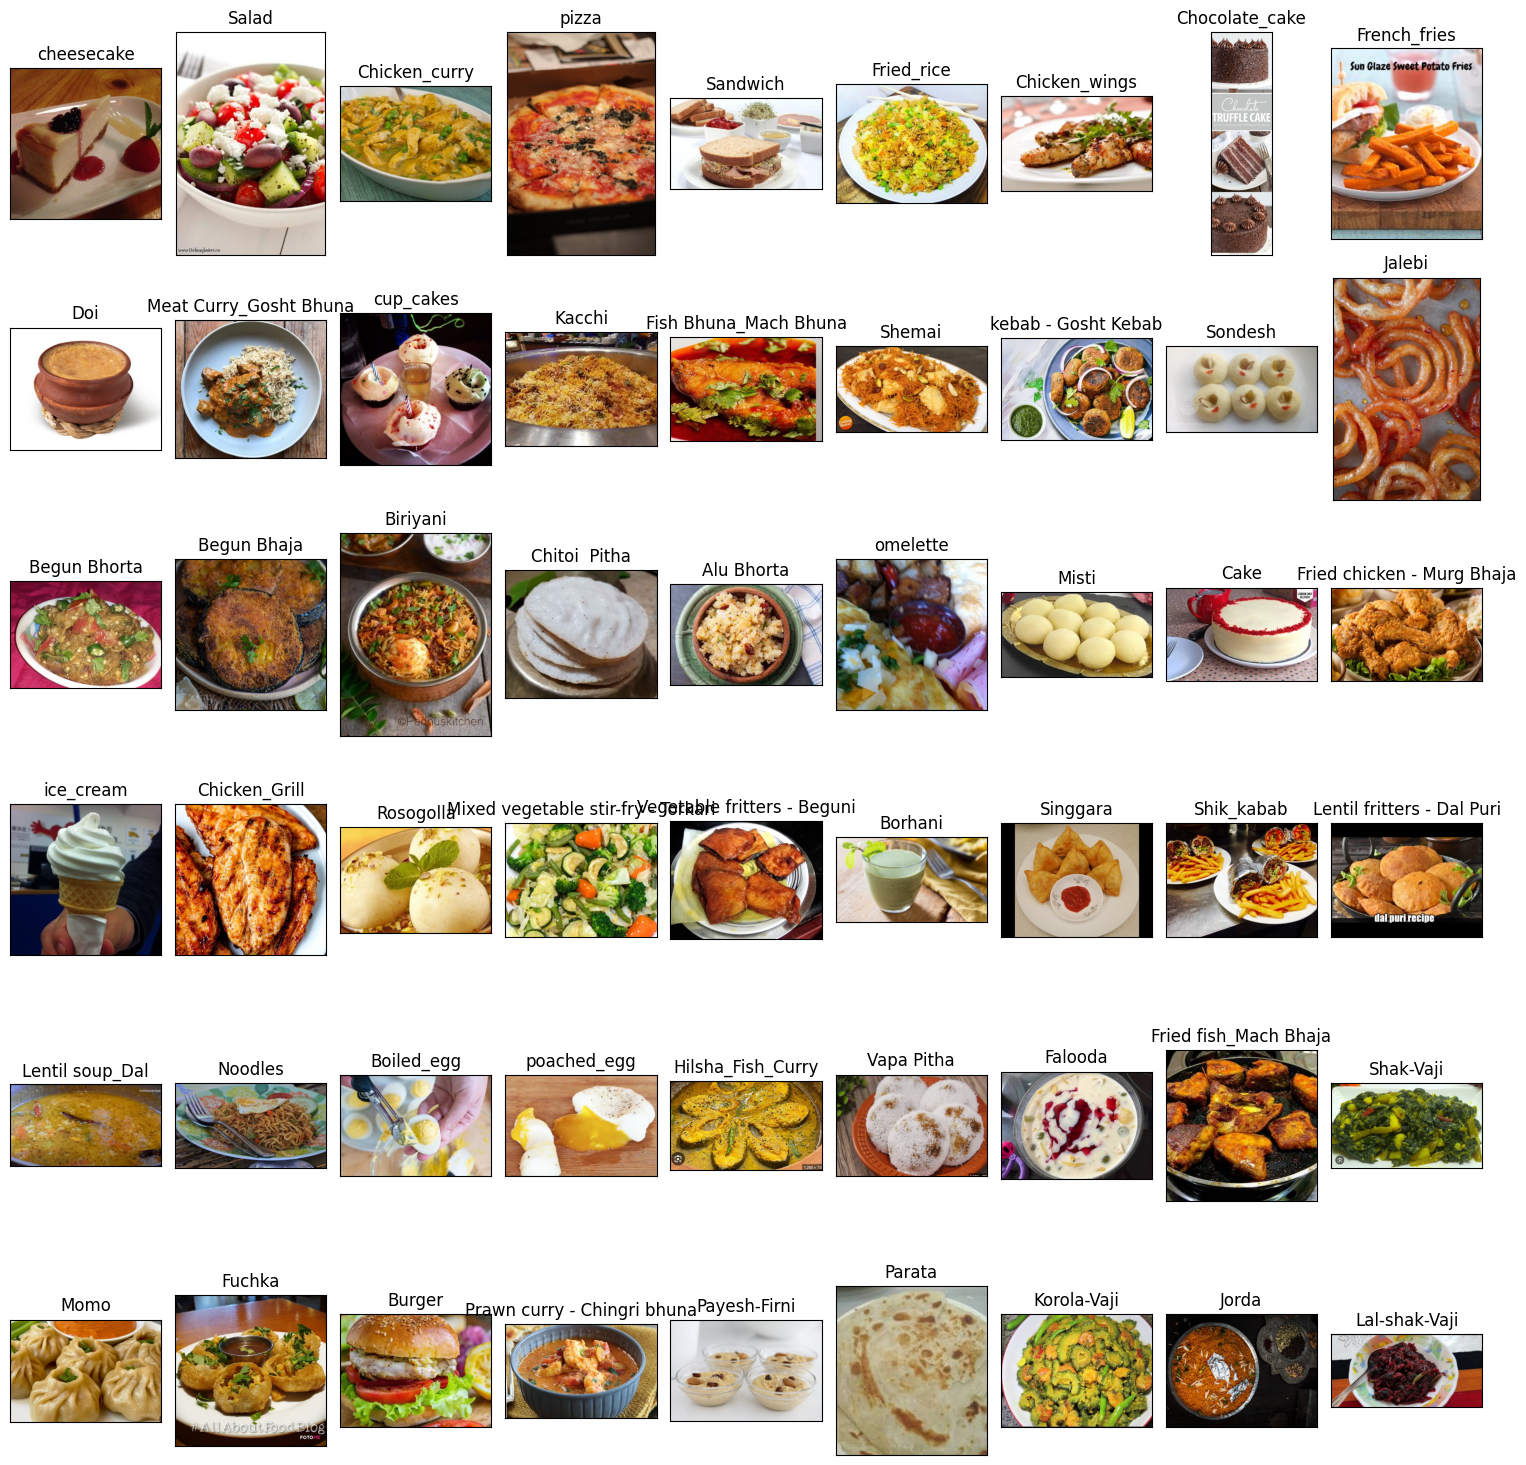

In [9]:
# Create a DataFrame with one Label of each category
df_unique = train_df.copy().drop_duplicates(subset=["Label"]).reset_index()

# Display some pictures of the dataset
fig, axes = plt.subplots(nrows=6, ncols=9, figsize=(15, 15),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(df_unique.Filepath[i]))
    ax.set_title(df_unique.Label[i], fontsize = 12)
plt.tight_layout(pad=1)
plt.show()

In [10]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [11]:
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=0,
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

Found 5415 validated image filenames belonging to 58 classes.


In [12]:
val_images = train_generator.flow_from_dataframe(
    dataframe=val_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=0,
    rotation_range=30,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

Found 272 validated image filenames belonging to 58 classes.


In [13]:
test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 272 validated image filenames belonging to 58 classes.


In [14]:
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)
pretrained_model.trainable = False

In [19]:
inputs = pretrained_model.input

x = tf.keras.layers.Dense(128, activation='relu')(pretrained_model.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)

outputs = tf.keras.layers.Dense(58, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    validation_data=val_images,
    batch_size = 32,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True
        )
    ]
)

Epoch 1/15
170/170 [==============================] - 23s 124ms/step - loss: 2.2288 - accuracy: 0.4388 - val_loss: 1.6039 - val_accuracy: 0.5588
Epoch 2/15
170/170 [==============================] - 20s 117ms/step - loss: 0.9409 - accuracy: 0.7276 - val_loss: 1.5205 - val_accuracy: 0.5809
Epoch 3/15
170/170 [==============================] - 20s 116ms/step - loss: 0.6145 - accuracy: 0.8175 - val_loss: 1.1941 - val_accuracy: 0.6581
Epoch 4/15
170/170 [==============================] - 20s 119ms/step - loss: 0.4049 - accuracy: 0.8842 - val_loss: 1.0815 - val_accuracy: 0.6875
Epoch 5/15
170/170 [==============================] - 20s 119ms/step - loss: 0.2582 - accuracy: 0.9306 - val_loss: 1.1594 - val_accuracy: 0.6912
Epoch 6/15
170/170 [==============================] - 20s 118ms/step - loss: 0.1747 - accuracy: 0.9577 - val_loss: 1.0875 - val_accuracy: 0.7059
Epoch 7/15
170/170 [==============================] - 20s 120ms/step - loss: 0.0992 - accuracy: 0.9825 - val_loss: 1.2206 - val_ac

In [20]:
pretrained_model.trainable = True

# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(pretrained_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in pretrained_model.layers[:fine_tune_at]:
  layer.trainable =  False

Number of layers in the base model:  155


In [21]:
history = model.fit(
    train_images,
    validation_data=val_images,
    batch_size = 32,
    epochs=15,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True
        )
    ]
)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Epoch 1/15
170/170 [==============================] - 21s 121ms/step - loss: 0.0034 - accuracy: 1.0000 - val_loss: 1.3409 - val_accuracy: 0.7169
Epoch 2/15
170/170 [==============================] - 21s 122ms/step - loss: 0.0029 - accuracy: 1.0000 - val_loss: 1.3356 - val_accuracy: 0.7169
Epoch 3/15
170/170 [==============================] - 20s 118ms/step - loss: 0.0024 - accuracy: 1.0000 - val_loss: 1.3615 - val_accuracy: 0.7206
Epoch 4/15
170/170 [==============================] - 20s 120ms/step - loss: 0.0021 - accuracy: 1.0000 - val_loss: 1.3943 - val_accuracy: 0.7132
Epoch 5/15
170/170 [==============================] - 20s 119ms/step - loss: 0.0018 - accuracy: 1.0000 - val_loss: 1.4018 - val_accuracy: 0.7096
Epoch 6/15
170/170 [==============================] - 21s 122ms/step - loss: 0.0015 - accuracy: 1.0000 - val_loss: 1.4204 - val_accuracy: 0.7169
Epoch 7/15
170/170 [==============================] - 20s 120ms/step - loss: 0.0013 - accuracy: 1.0000 - val_loss: 1.4390 - val_ac

In [22]:
# Predict the label of the test_images
pred = model.predict(test_images)
pred = np.argmax(pred,axis=1)
# Map the label
labels = (train_images.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred1 = [labels[k] for k in pred]
pred1

9/9 [==============================] - 2s 131ms/step


['Lal-shak-Vaji',
 'Chocolate_cake',
 'Chicken_Grill',
 'Chitoi  Pitha',
 'Payesh-Firni',
 'French_fries',
 'Boiled_egg',
 'Doi',
 'ice_cream',
 'Vapa Pitha',
 'Lal-shak-Vaji',
 'Misti',
 'Doi',
 'Lal-shak-Vaji',
 'Meat Curry_Gosht Bhuna',
 'cheesecake',
 'Parata',
 'Alu-Vaji',
 'pizza',
 'Mixed vegetable stir-fry - Torkari',
 'cheesecake',
 'Chicken_curry',
 'Rosogolla',
 'Fried_rice',
 'Tundul ruti - Nan Ruti',
 'Fish Bhuna_Mach Bhuna',
 'Meat Curry_Gosht Bhuna',
 'Lentil soup_Dal',
 'Mixed vegetable stir-fry - Torkari',
 'Momo',
 'Shak-Vaji',
 'Momo',
 'Fuchka',
 'Khichuri',
 'ice_cream',
 'cheesecake',
 'Lal-shak-Vaji',
 'ice_cream',
 'Chicken_curry',
 'kebab - Gosht Kebab',
 'Lentil fritters - Dal Puri',
 'Shak-Vaji',
 'Burger',
 'pizza',
 'Chicken_Grill',
 'Begun Bhaja',
 'Vapa Pitha',
 'Fish Bhuna_Mach Bhuna',
 'Cake',
 'Misti',
 'Doi',
 'Chicken_curry',
 'Momo',
 'Jalebi',
 'Rosogolla',
 'Chicken_curry',
 'Tundul ruti - Nan Ruti',
 'Chocolate_cake',
 'Fried chicken - Murg Bhaja

In [23]:
def output(location):
    img=load_img(location,target_size=(224,224,3))
    img=img_to_array(img)
    img=img/255
    img=np.expand_dims(img,[0])
    answer=model.predict(img)
    y_class = answer.argmax(axis=-1)
    y = " ".join(str(x) for x in y_class)
    y = int(y)
    res = labels[y]
    return res

In [28]:
img = output(r'C:/Users/Rafin/OneDrive/Desktop/NSU/NSU 10th Semester/CSE299/PROJECT/MobileNet_Test_Images/i.jpg')
img

1/1 [==============================] - 0s 22ms/step


'Fried chicken - Murg Bhaja'

In [32]:
model.save('Food_FineTuned.h5')